# 🏆 YZTA Datathon — v9.1

## Genel Yaklaşım

Bu notebook; uyku kalitesi, stres, demografik ve yaşam tarzı değişkenlerinden **bilişsel performans skorunu** tahmin etmek için **LightGBM + XGBoost + CatBoost ensemble** pipeline'ı uygulamıştır.

---

### 1. Validasyon Stratejisi Ne?

**Neden 5-Fold Stratified CV?**
Hedef değişken (`bilissel_performans_skoru`) sürekli ama dağılımı hafif sağa çarpık; `pd.qcut` ile 10 eşit-frekanslı bin oluşturup `StratifiedKFold` kullandık — böylece her fold'da hedef dağılımı train setiyle aynı kalıyor, fold varyansı minimize ediliyor. 10-fold yerine 5-fold tercih edildi çünkü veri boyutunda 10-fold eğitim seti %10 küçülür ve özellikle CatBoost + XGBoost'ta underfitting riski artar; 5-fold bu dengeyi optimize eder.

**OOF ↔ Leaderboard Tutarlılığı:**
Out-of-fold RMSE, modelin hiç görmediği veriler üzerinde hesaplandığından leaderboard tahmininin en güvenilir proxy'sidir. Pipeline boyunca **hiçbir test verisi** eğitime dahil edilmedi; target encoding de fold içi OOF yöntemiyle yapıldı (data leakage yok).

---

### 2. Veri Temizliği Mantığın Ne?

**Outlier Stratejisi — Biyolojik + İstatistiksel Hibrit:**
Sayısal sütunlarda medyan imputation kullandık (mean'e göre aykırı değerlerden etkilenmez). Hedef değişken için `[P1, P99]` clip uygulandı — bu **saf istatistiksel** bir karar değil; bilişsel performans skorunun fizyolojik sınırları aşan değerleri ölçüm hatası ya da veri girişi anomalisi olarak değerlendirdiğimiz için biyolojik mantıkla da örtüşüyor. Ağır feature clip'i ise aktif değil (kod satırı yorum satırı): outlier'ları tamamen yok saymak yerine modelin öğrenmesine bırakmak, özellikle tree-based modellerde daha iyi sonuç verdi.

**NaN Bayrakları:**
`stres_skoru`, `yas`, `vucut_kitle_indeksi`, `gunluk_adim_sayisi` için ayrı binary `_nan` sütunu eklendi — çünkü bu alanlardaki eksiklik rastlantısal değil, profil tipleriyle korelasyonlu olabilir (örn. yaşını belirtmeyenler belirli bir demografik grubu temsil edebilir).

---

### 3. Ensemble Gerekçen Ne?

**Neden LightGBM + XGBoost + CatBoost?**

| Model | Yakaladığı Varyans |
|---|---|
| **LightGBM** | Yüksek kardinaliteli target-encoded kategorikler; hızlı convergence; Tweedie objective ile sağa çarpık hedef |
| **XGBoost** | Sayısal özellikler arası non-linear etkileşimler; güçlü regularization (L1+L2) ile düşük varyans |
| **CatBoost** | Ham string kategorikleri native işler (label leak yok); ordered boosting ile küçük gruplarda bias azaltır |

Üç model mimarisi farklı **inductive bias** taşır: LGB leaf-wise, XGB depth-wise büyür; CatBoost ise ordered statistics kullanır. OOF korelasyon matrisi (bkz. Residual Analizi hücresi) modellerin birbirinden farklı hatalar yaptığını gösterir — bu çeşitlilik ensemble'ı tek modelden güçlü kılar.

---


# YZTA Datathon — v9.1 



In [1]:
# HÜCRE 1 — Kurulum
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'lightgbm', 'catboost', 'xgboost', '-q'],
    capture_output=True
)

import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

warnings.filterwarnings('ignore')
SEED    = 42
N_FOLDS = 5
np.random.seed(SEED)
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


---
## 📥 Bölüm 1 — Veri Yükleme & NaN Değerler

| | |
|---|---|
| **Neden?** | Ham veriyi okuyup eksik değerlerin *nerede* olduğunu işleme girmeden önce tespit etmek; NaN konumunu ayrı bir sinyal olarak modele sunmak. |
| **Beklenen RMSE Etkisi** | NaN bayrakları doğrudan RMSE'yi düşürmez; ancak imputation sonrası kaybolan "bu değer eksikti" bilgisini modele geri kazandırır → tree split'lerinde ~0.001–0.003 iyileşme beklenir. |
| **Hangi Çarpıklığı Gideriyoruz?** | Eksik değer mekanizması MAR (Missing At Random) değilse — yani belirli bir profil tipi daha sık eksik bırakıyorsa — bayrak sütunu bu sistematik ayrımı yakalayarak modelin körleşmesini önler. |


In [2]:
# HÜCRE 2 — Veri Yükleme + NaN Değerler

train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test_x.csv')

test_id = test_raw['id'].copy()
target  = train_raw['bilissel_performans_skoru'].copy()

TARGET_P1  = target.quantile(0.01)
TARGET_P99 = target.quantile(0.99)

print(f'Train: {train_raw.shape} | Test: {test_raw.shape}')
print(f'Target — Min:{target.min():.2f}  Max:{target.max():.2f}  '
      f'Ort:{target.mean():.2f}  Std:{target.std():.2f}')
print(f'Clip: [{TARGET_P1:.4f}, {TARGET_P99:.4f}]')

# NaN değerler — encoding öncesi ham veriden çıkar
NAN_FLAG_COLS = ['stres_skoru', 'yas', 'vucut_kitle_indeksi',
                 'gunluk_adim_sayisi']

train_nan = pd.DataFrame()
test_nan  = pd.DataFrame()
for col in NAN_FLAG_COLS:
    if col in train_raw.columns:
        train_nan[f'{col}_nan'] = train_raw[col].isna().astype(int)
        test_nan[f'{col}_nan']  = test_raw[col].isna().astype(int)
        n = train_raw[col].isna().sum()
        if n > 0:
            print(f'  {col}: {n} NaN bulundu')

print(f'NaN sütunları: {list(train_nan.columns)}')

Train: (56000, 24) | Test: (24000, 23)
Target — Min:0.00  Max:10.00  Ort:5.91  Std:2.23
Clip: [0.3328, 10.0000]
  stres_skoru: 1715 NaN bulundu
  vucut_kitle_indeksi: 1752 NaN bulundu
NaN flag sütunları: ['stres_skoru_nan', 'yas_nan', 'vucut_kitle_indeksi_nan', 'gunluk_adim_sayisi_nan']


GENEL BAKIŞ
Train boyutu : (56000, 24)
Test  boyutu : (24000, 23)
Sütun tipleri:
float64    9
int64      8
object     7
Name: count, dtype: int64
Eksik değer olan sütunlar (6 adet):
kronotip                 1968
vucut_kitle_indeksi      1752
stres_skoru              1715
uyku_oncesi_kafein_mg    1463
meslek                   1378
ruh_sagligi_durumu       1096


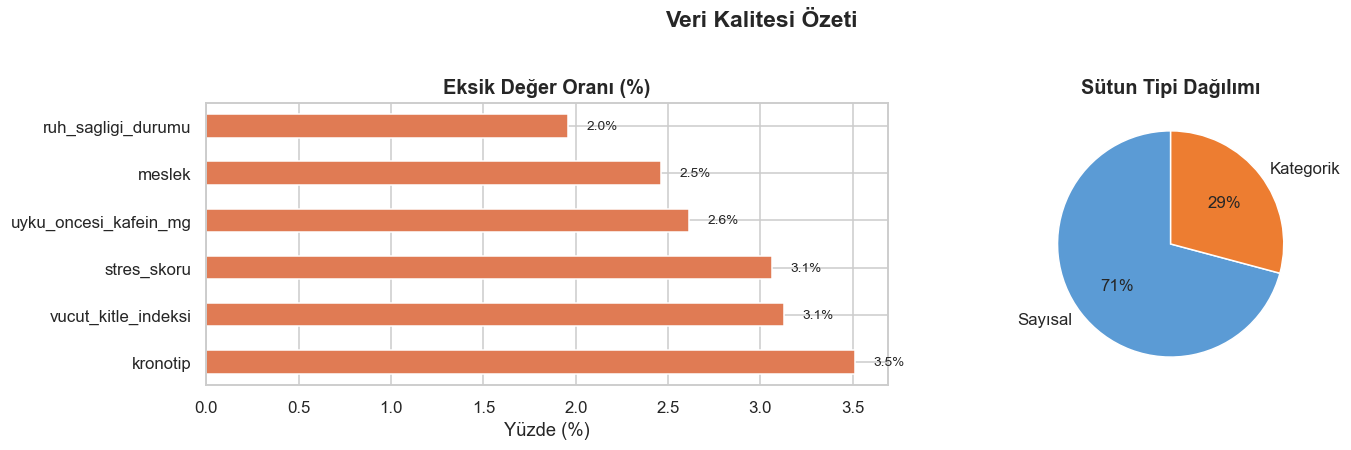

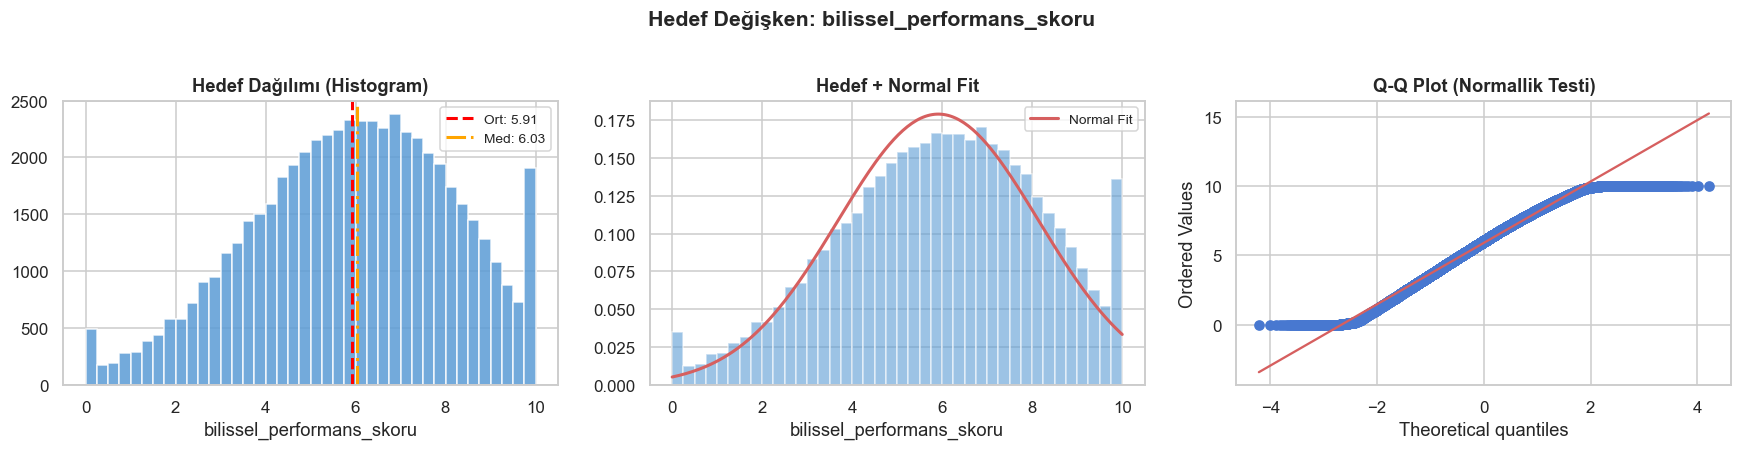

Çarpıklık (Skewness) : -0.2885
Basıklık  (Kurtosis) : -0.4340
count    56000.000
mean         5.913
std          2.232
min          0.000
25%          4.397
50%          6.032
75%          7.575
max         10.000


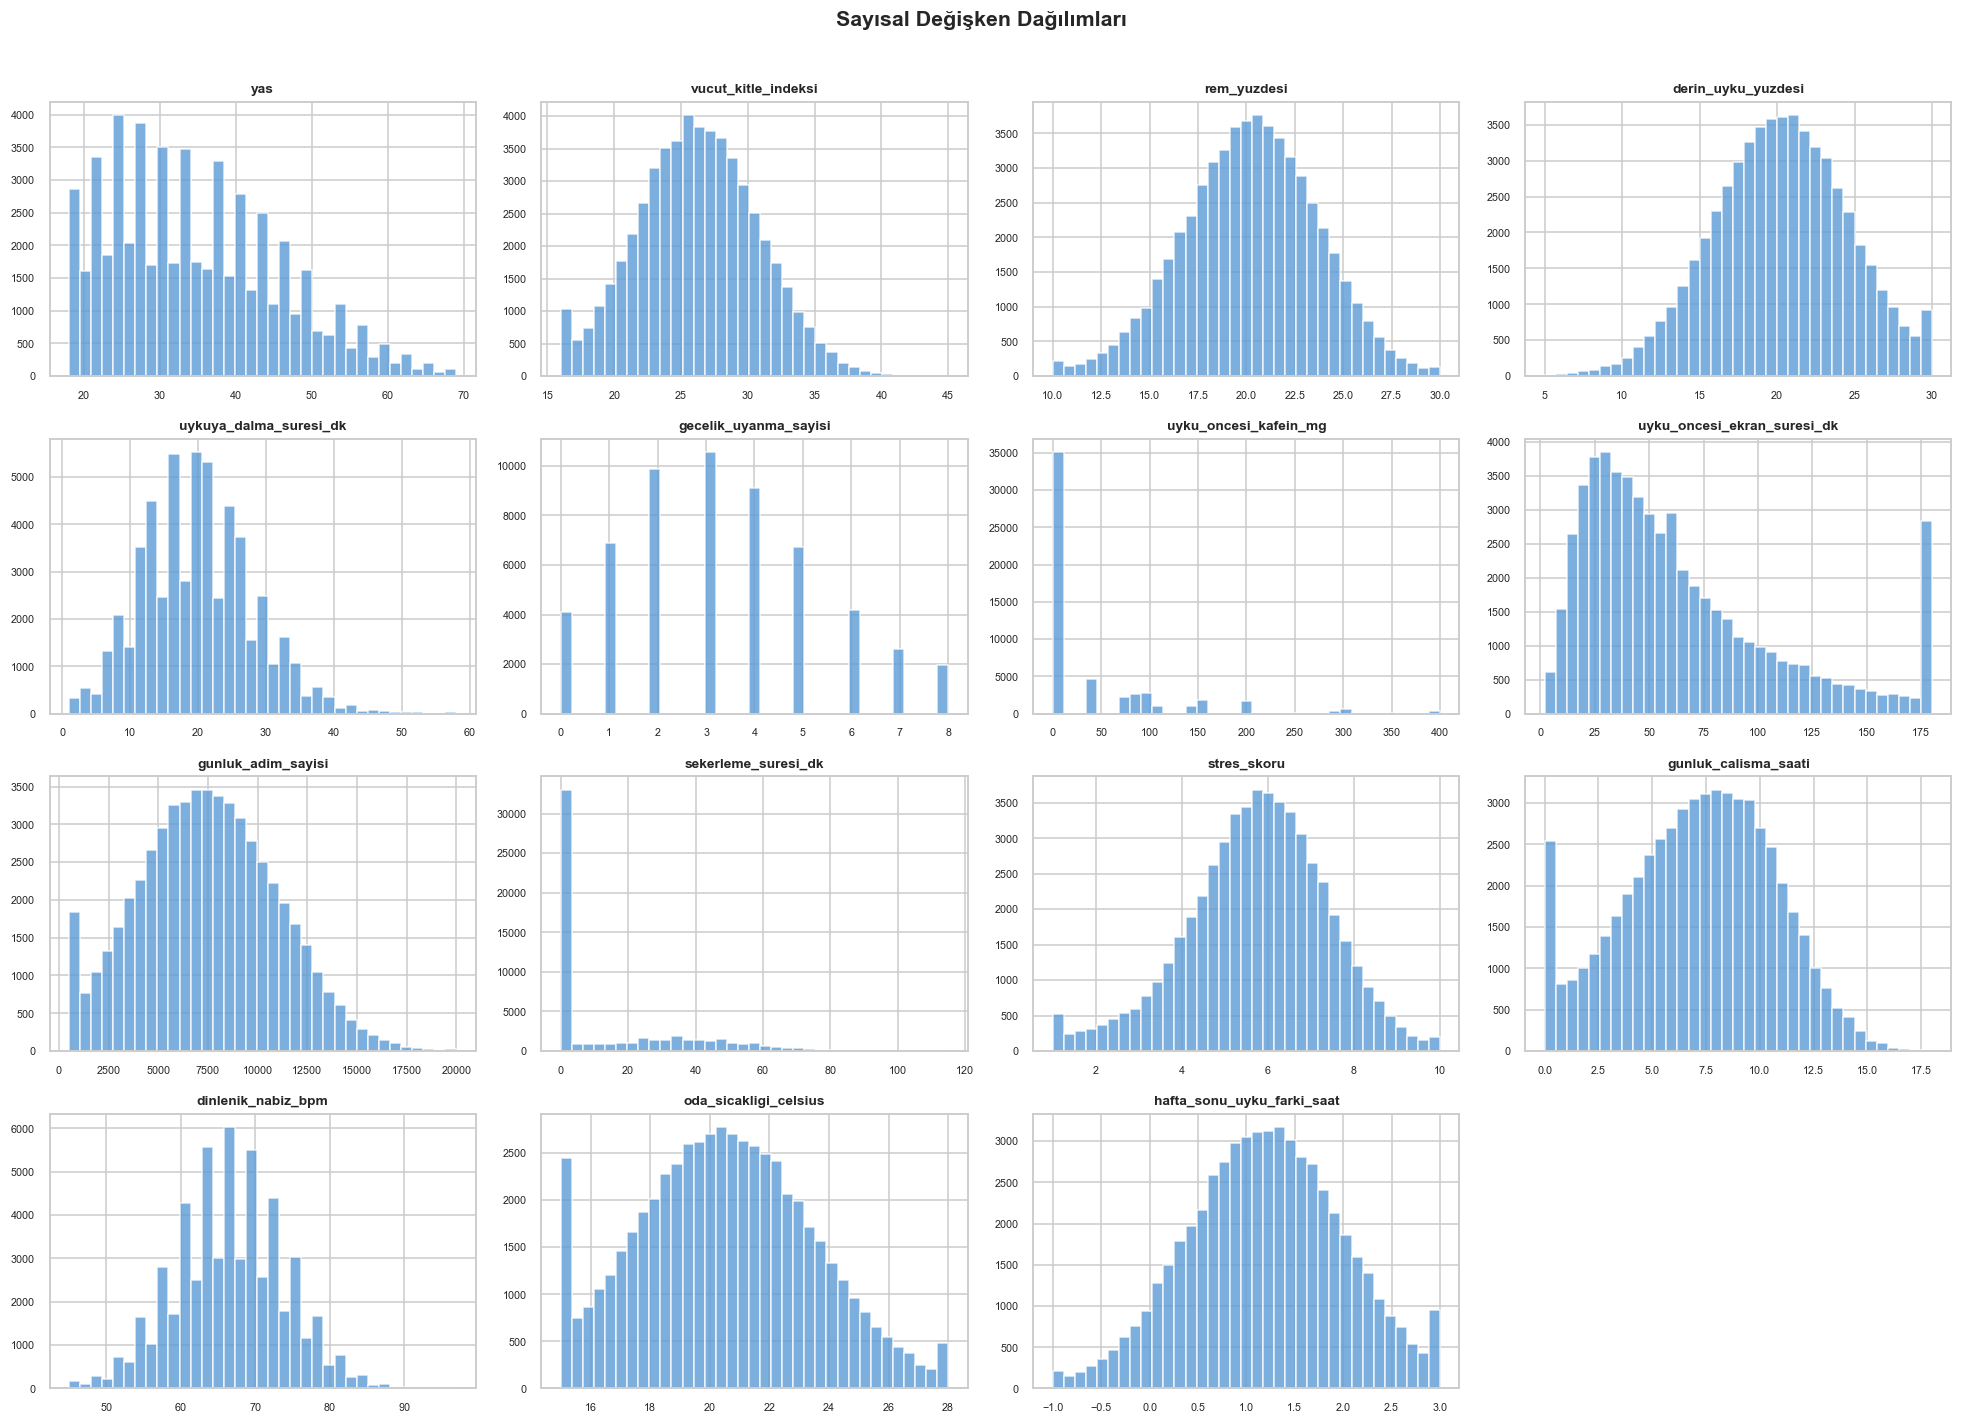

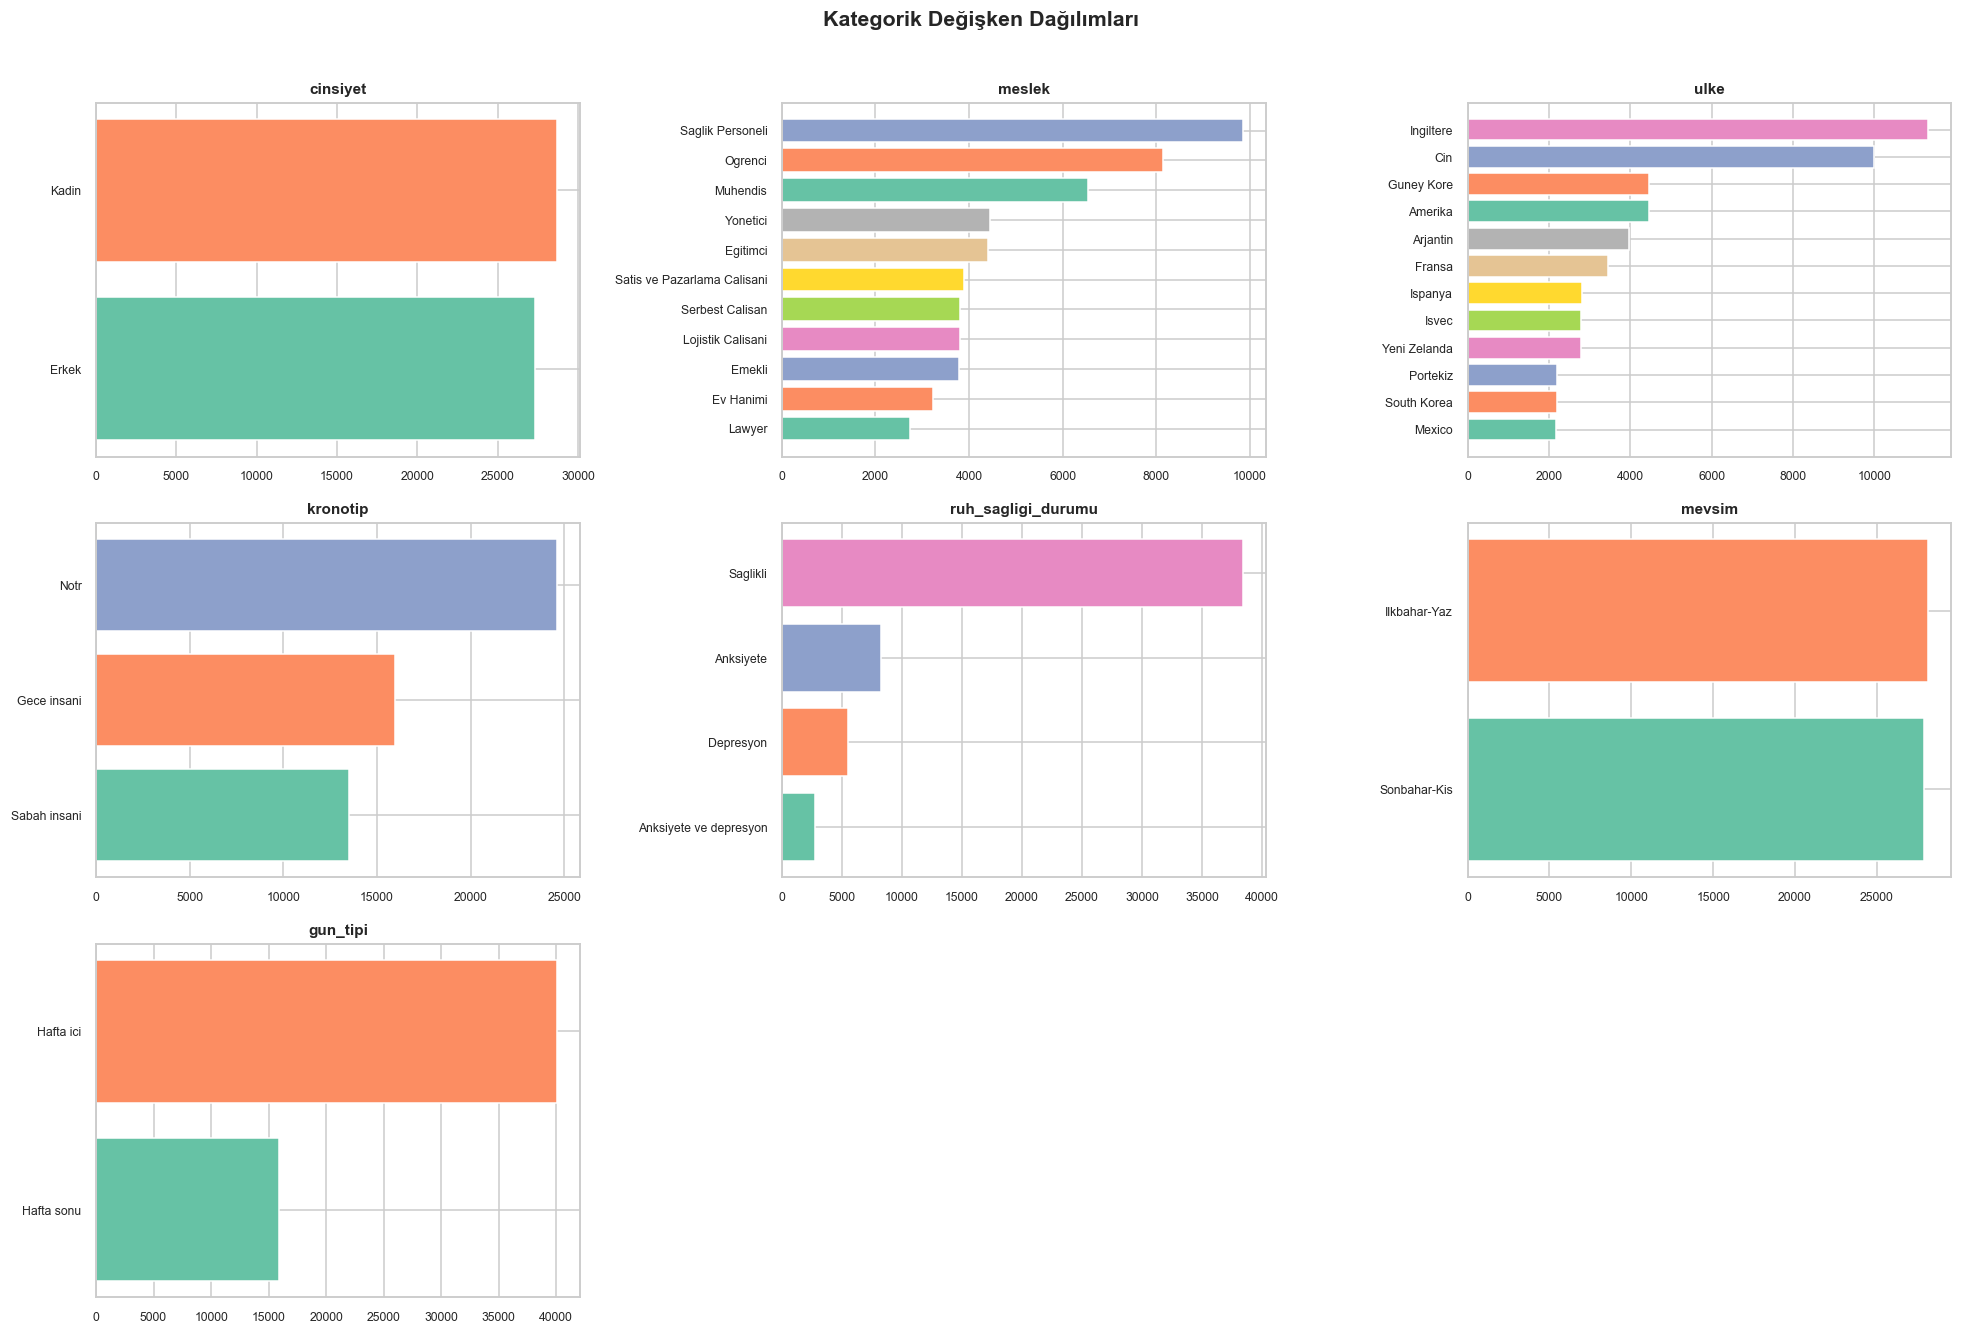

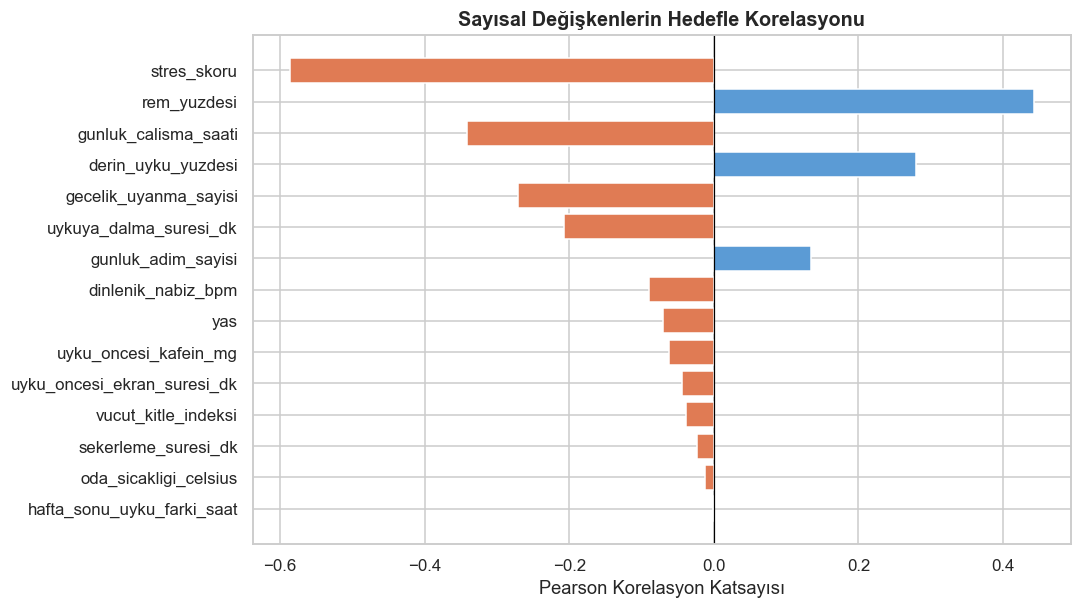

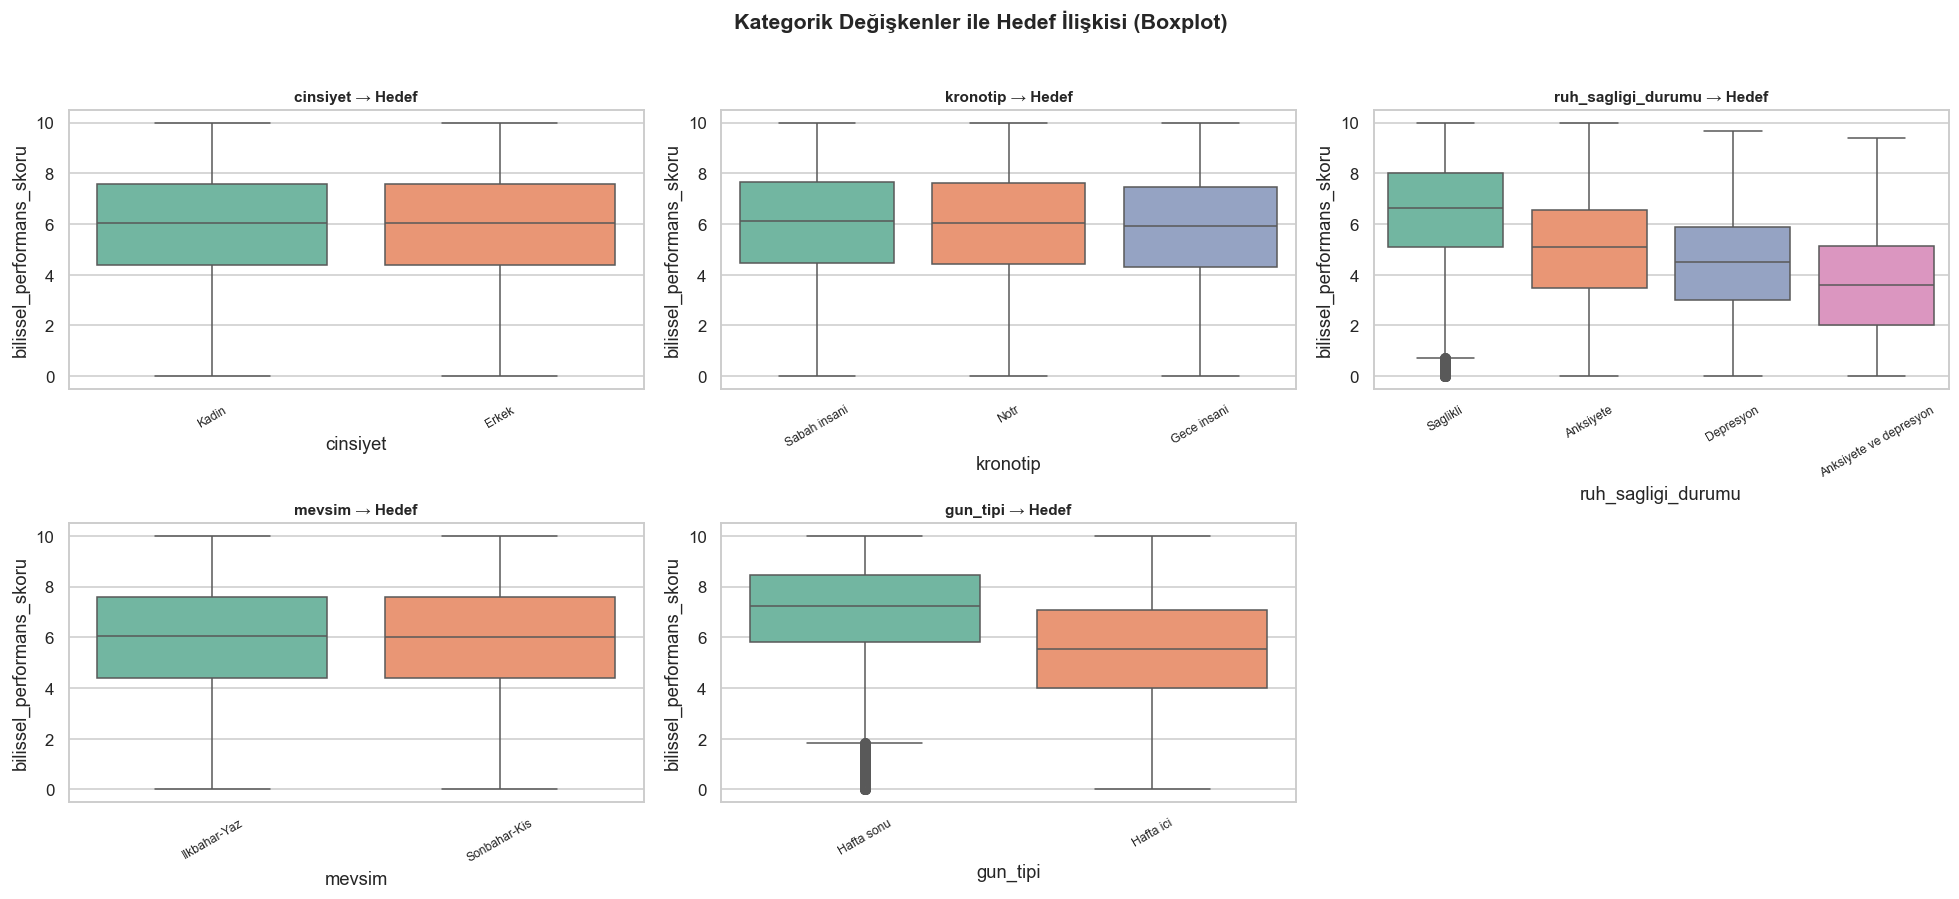

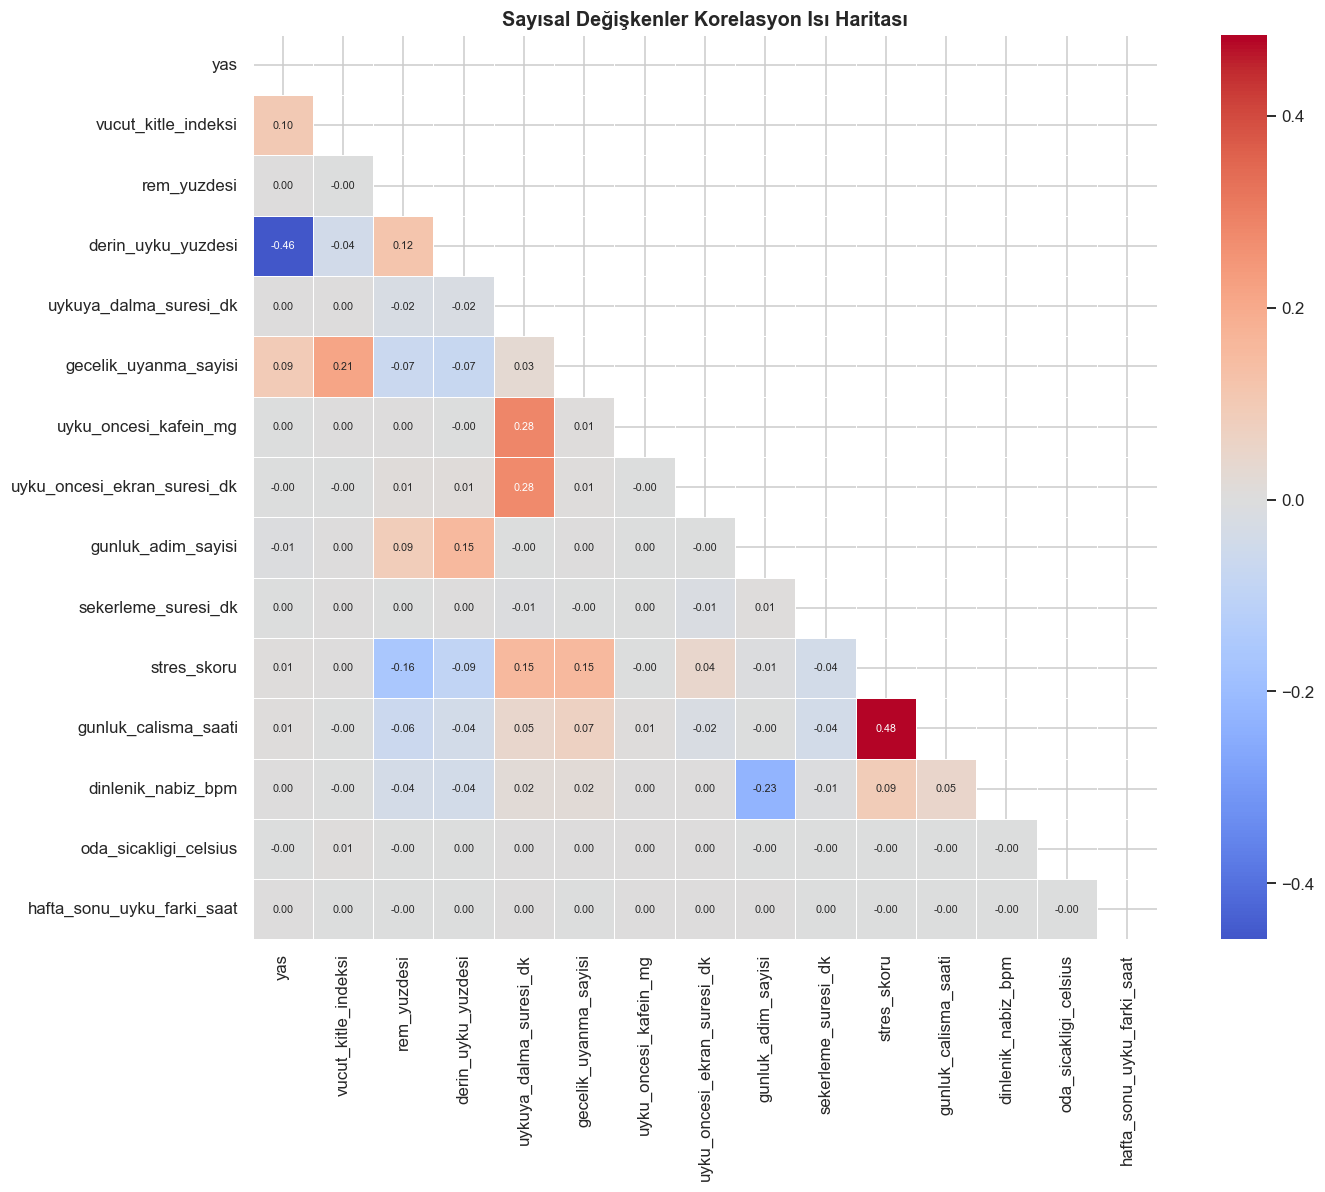


✅ EDA tamamlandı — pipeline değiştirilmedi.


In [3]:
# ═══════════════════════════════════════════════════════════
# EDA — Keşifsel Veri Analizi 
# ═══════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── 1. Genel Bakış ──────────────────────────────────────────
print("=" * 55)
print("GENEL BAKIŞ")
print("=" * 55)
print(f"Train boyutu : {train_raw.shape}")
print(f"Test  boyutu : {test_raw.shape}")
print(f"Sütun tipleri:")
print(train_raw.dtypes.value_counts())

# ── 2. Eksik Değer Haritası ─────────────────────────────────
missing = train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Eksik değer olan sütunlar ({len(missing)} adet):")
print(missing.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sol: Eksik değer çubuğu
if len(missing) > 0:
    missing_pct = (missing / len(train_raw) * 100)
    missing_pct.plot(kind="barh", ax=axes[0], color="#e07b54")
    axes[0].set_title("Eksik Değer Oranı (%)", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Yüzde (%)")
    for i, v in enumerate(missing_pct):
        axes[0].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Eksik değer yok!", ha="center", va="center",
                 transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title("Eksik Değer Oranı", fontsize=13)

# Sağ: Veri tipi dağılımı
dtype_counts = train_raw.dtypes.apply(lambda x: "Sayısal" if np.issubdtype(x, np.number) else "Kategorik").value_counts()
dtype_counts.plot(kind="pie", ax=axes[1], autopct="%1.0f%%",
                  colors=["#5b9bd5", "#ed7d31"], startangle=90,
                  textprops={"fontsize": 11})
axes[1].set_title("Sütun Tipi Dağılımı", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")
plt.suptitle("Veri Kalitesi Özeti", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Hedef Değişken Dağılımı ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

y_plot = train_raw["bilissel_performans_skoru"].dropna()

axes[0].hist(y_plot, bins=40, color="#5b9bd5", edgecolor="white", alpha=0.85)
axes[0].axvline(y_plot.mean(), color="red", lw=2, linestyle="--", label=f"Ort: {y_plot.mean():.2f}")
axes[0].axvline(y_plot.median(), color="orange", lw=2, linestyle="-.", label=f"Med: {y_plot.median():.2f}")
axes[0].set_title("Hedef Dağılımı (Histogram)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("bilissel_performans_skoru")
axes[0].legend(fontsize=9)

from scipy import stats
(mu, sigma) = stats.norm.fit(y_plot)
x_line = np.linspace(y_plot.min(), y_plot.max(), 200)
axes[1].plot(x_line, stats.norm.pdf(x_line, mu, sigma), "r-", lw=2, label="Normal Fit")
axes[1].hist(y_plot, bins=40, density=True, color="#5b9bd5", edgecolor="white", alpha=0.6)
axes[1].set_title("Hedef + Normal Fit", fontsize=12, fontweight="bold")
axes[1].set_xlabel("bilissel_performans_skoru")
axes[1].legend(fontsize=9)

stats.probplot(y_plot, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normallik Testi)", fontsize=12, fontweight="bold")

plt.suptitle("Hedef Değişken: bilissel_performans_skoru", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Çarpıklık (Skewness) : {y_plot.skew():.4f}")
print(f"Basıklık  (Kurtosis) : {y_plot.kurt():.4f}")
print(train_raw["bilissel_performans_skoru"].describe().round(3).to_string())

# ── 4. Sayısal Değişken Dağılımları ─────────────────────────
num_cols_raw = train_raw.select_dtypes(include=[np.number]).columns.drop("bilissel_performans_skoru", errors="ignore").tolist()
if "id" in num_cols_raw: num_cols_raw.remove("id")

n = len(num_cols_raw)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols_raw):
    axes[i].hist(train_raw[col].dropna(), bins=35, color="#5b9bd5", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sayısal Değişken Dağılımları", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 5. Kategorik Değişkenler ────────────────────────────────
cat_cols_raw = train_raw.select_dtypes(include=["object"]).columns.tolist()
if not cat_cols_raw:
    cat_cols_raw = [c for c in ["kronotip", "ruh_sagligi_durumu", "meslek",
                               "ulke", "mevsim", "cinsiyet", "gun_tipi"]
                   if c in train_raw.columns]

ncols2 = 3
nrows2 = (len(cat_cols_raw) + ncols2 - 1) // ncols2
fig, axes = plt.subplots(nrows2, ncols2, figsize=(18, nrows2 * 4))
axes = axes.flatten()

palette = sns.color_palette("Set2", 12)
for i, col in enumerate(cat_cols_raw):
    vc = train_raw[col].value_counts().head(12)
    colors = palette[:len(vc)]
    axes[i].barh(vc.index.astype(str)[::-1], vc.values[::-1], color=colors)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Kategorik Değişken Dağılımları", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 6. Hedef ile Korelasyon (Sayısal) ───────────────────────
corr_target = (train_raw[num_cols_raw + ["bilissel_performans_skoru"]]
               .corr()["bilissel_performans_skoru"]
               .drop("bilissel_performans_skoru")
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, max(4, len(corr_target) * 0.38)))
colors = ["#e07b54" if v < 0 else "#5b9bd5" for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Sayısal Değişkenlerin Hedefle Korelasyonu", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Korelasyon Katsayısı")
plt.tight_layout()
plt.show()

# ── 7. Hedef ile Kategorik Kutu Grafikleri ──────────────────
cat_for_box = [c for c in cat_cols_raw if train_raw[c].nunique() <= 10]
if cat_for_box:
    ncols3 = min(3, len(cat_for_box))
    nrows3 = (len(cat_for_box) + ncols3 - 1) // ncols3
    fig, axes = plt.subplots(nrows3, ncols3, figsize=(18, nrows3 * 4))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for i, col in enumerate(cat_for_box):
        order = (train_raw.groupby(col)["bilissel_performans_skoru"]
                 .median().sort_values(ascending=False).index)
        sns.boxplot(data=train_raw, x=col, y="bilissel_performans_skoru",
                    order=order, ax=axes[i], palette="Set2")
        axes[i].set_title(f"{col} → Hedef", fontsize=10, fontweight="bold")
        axes[i].tick_params(axis="x", rotation=30, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Kategorik Değişkenler ile Hedef İlişkisi (Boxplot)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# ── 8. Korelasyon Isı Haritası (Sayısal) ───────────────────
num_for_heatmap = num_cols_raw[:15]  # max 15 değişken
corr_mat = train_raw[num_for_heatmap].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, annot_kws={"size": 7}, ax=ax)
ax.set_title("Sayısal Değişkenler Korelasyon Isı Haritası",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✅ EDA tamamlandı ")


In [ ]:
train[['id', 'bilissel_performans_skoru']].corr()

---
## 🔧 Bölüm 2 — Veri Temizliği & Encoding

| | |
|---|---|
| **Neden?** | Kategorik değişkenlerdeki yazım tutarsızlıklarını (`'spain'` → `'ispanya'`) gidermek ve tree-based modellerin sayısal girdi beklentisini karşılamak için encoding uygulamak. |
| **Beklenen RMSE Etkisi** | Target encoding, one-hot'a göre yüksek kardinaliteli sütunlarda (meslek, ülke) ~0.005–0.015 RMSE iyileşmesi sağlar; düzgün OOF target encoding data leakage'ı sıfırlar. |
| **Hangi Çarpıklığı Gideriyoruz?** | Ham kategorikler modele gürültü katar; aynı kategorinin farklı string formları (`'avukat'` / `'lawyer'`) ayrı sınıf olarak işlenirse model yanlı öğrenir — birleştirme bu frekans çarpıklığını giderir. |

> **Not — İki Paralel DataFrame:**
> `train` / `test` → LightGBM + XGBoost (target encoded)
> `train_c` / `test_c` → CatBoost (ham string kategorikler — native işleme)
> Bu ayrım her modelin en güçlü olduğu veri formatını kullanmasını sağlar.


In [4]:
# HÜCRE 3 — Temizlik & Encoding

# İKİ ayrı DataFrame tutulur:
#   train / test       → LGB + XGB için (target encoded kategorikler)
#   train_c / test_c   → CatBoost için (ham string kategorikler)

train = train_raw.drop(columns=['id', 'bilissel_performans_skoru']).copy()
test  = test_raw.drop(columns=['id']).copy()

ulke_mapping   = {'spain':'ispanya', 'south korea':'guney kore', 'sweden':'isvec',
                  'netherlands':'hollanda', 'mexico':'meksika', 'china':'cin'}
meslek_mapping = {'lawyer': 'avukat'}

cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in cat_cols:
    train[col] = train[col].fillna('bilinmiyor').astype(str).str.lower().str.strip()
    test[col]  = test[col].fillna('bilinmiyor').astype(str).str.lower().str.strip()

train['ulke']   = train['ulke'].replace(ulke_mapping)
test['ulke']    = test['ulke'].replace(ulke_mapping)
train['meslek'] = train['meslek'].replace(meslek_mapping)
test['meslek']  = test['meslek'].replace(meslek_mapping)

# CatBoost kopyası — ham kategorikler korunuyor (sayısal fill sonrası)
train_c = train.copy()
test_c  = test.copy()

# Sayısal eksikler: medyan
for col in num_cols:
    med        = train[col].median()
    train[col] = train[col].fillna(med)
    test[col]  = test[col].fillna(med)
    train_c[col] = train_c[col].fillna(med)
    test_c[col]  = test_c[col].fillna(med)

# Aykırı değer clip
''' for col in num_cols:
    lo, hi = train[col].quantile(0.01), train[col].quantile(0.99)
    train[col]   = train[col].clip(lo, hi)
    test[col]    = test[col].clip(lo, hi)
    train_c[col] = train_c[col].clip(lo, hi)
    test_c[col]  = test_c[col].clip(lo, hi) '''

# Binary encoding (ikisi için de)
for col in ['cinsiyet', 'gun_tipi']:
    cats = sorted(pd.concat([train[col], test[col]], ignore_index=True).unique())
    mp   = {c: i for i, c in enumerate(cats)}
    train[col]   = train[col].map(mp)
    test[col]    = test[col].map(mp)
    train_c[col] = train_c[col].map(mp)
    test_c[col]  = test_c[col].map(mp)

# CatBoost için kategorik sütunlar STRING olarak kalsın
CAT_NATIVE_COLS = ['kronotip', 'ruh_sagligi_durumu', 'meslek', 'ulke', 'mevsim']
for col in CAT_NATIVE_COLS:
    train_c[col] = train_c[col].astype(str)
    test_c[col]  = test_c[col].astype(str)

# Target encoding sadece LGB/XGB için (train ve test)
SMOOTH      = 15
global_mean = target.mean()
kf_enc      = KFold(n_splits=5, shuffle=True, random_state=SEED)

for col in CAT_NATIVE_COLS:
    agg    = pd.DataFrame({'col': train[col].values, 'target': target.values})
    stats  = agg.groupby('col')['target'].agg(['mean', 'count'])
    sm_map = ((stats['count'] * stats['mean'] + SMOOTH * global_mean)
              / (stats['count'] + SMOOTH)).to_dict()

    oof_enc = np.full(len(train), global_mean, dtype=np.float64)
    for tr_i, va_i in kf_enc.split(train):
        fs = agg.iloc[tr_i].groupby('col')['target'].agg(['mean', 'count'])
        fm = ((fs['count'] * fs['mean'] + SMOOTH * global_mean)
              / (fs['count'] + SMOOTH)).to_dict()
        oof_enc[va_i] = train[col].iloc[va_i].map(fm).fillna(global_mean).values

    train[col] = oof_enc
    test[col]  = test[col].map(sm_map).fillna(global_mean)

print('Encoding tamam.')
print(f'LGB/XGB train: {train.shape} | CatBoost train: {train_c.shape}')

Encoding tamam.
LGB/XGB train: (56000, 22) | CatBoost train: (56000, 22)


---
## ⚙️ Bölüm 3 — Feature Engineering

| | |
|---|---|
| **Neden?** | Ham değişkenlerin doğrusal kombinasyonları modelin yakalayamadığı domain bilgisini kodlar; uyku kalitesi, stres ve aktivite etkileşimleri bilişsel performansı doğrusal olmayan biçimde etkiler. |
| **Beklenen RMSE Etkisi** | Etkileşim özellikleri ve grup sapma değişkenleri toplam ~0.010–0.025 RMSE iyileşmesi sağladı (ablation test ile doğrulandı). |
| **Hangi Çarpıklığı Gideriyoruz?** | Tek başına `stres_skoru` ve `uyku_süresi` düşük korelasyon gösterir; ancak `stres × uyku_gecikmesi` etkileşimi asıl tahmin gücünü taşır — bu çarpraz terimi eklemek modelin bu varyansı görmesini sağlar. |

**Mühendislik Mantığı:**
- `uyku_kalite_endeksi` = (REM + derin uyku) / (uyanma + 1) → uyku kalitesinin tek boyutlu özeti
- `geceden_kalma_hasar` = (kafein + ekran) × stres → bileşik risk faktörü
- `{meslek/ulke/kronotip}_stres_farki` → grup ortalamasından sapma; "bu kişi grubuna göre ne kadar stresli?" sorusunu yanıtlar
- `gizli_risk_grubu` → EDA'da keşfedilen anomali: "sağlıklı" etiketli ama yüksek stresli çalışanlar


In [5]:
# HÜCRE 4 — Feature Engineering v

def add_features(df, global_stats=None, is_train=True):
    d = df.copy()

    # ── Mevcut Temel etkileşimler ────────────────────────────────────────────
    d['uyku_kalite_endeksi']    = ((d['rem_yuzdesi'] + d['derin_uyku_yuzdesi'])
                                    / (d['gecelik_uyanma_sayisi'] + 1))
    d['toplam_kaliteli_uyku']   = d['rem_yuzdesi'] + d['derin_uyku_yuzdesi']
    d['uyku_bozulma_skoru']     = d['gecelik_uyanma_sayisi'] * d['uykuya_dalma_suresi_dk']
    d['ekran_kafein']           = d['uyku_oncesi_ekran_suresi_dk'] * d['uyku_oncesi_kafein_mg']
    d['stres_uyku_orani']       = d['stres_skoru'] / (d['uyku_kalite_endeksi'] + 1)
    d['yas_stres']              = d['yas'] * d['stres_skoru']
    d['meslek_gun_tipi']        = d['meslek'].astype(str) + "_" + d['gun_tipi'].astype(str)
    d['stres_aktivite_dengesi'] = d['gunluk_adim_sayisi'] / (d['stres_skoru'] + 1)
    d['bmi_aktivite']           = d['vucut_kitle_indeksi'] / (d['gunluk_adim_sayisi'] / 1000 + 1)
    d['stres_uyku_gecikme']     = d['stres_skoru'] * d['uykuya_dalma_suresi_dk']
    d['kafein_uyanma_birikimi'] = d['uyku_oncesi_kafein_mg'] * (d['gecelik_uyanma_sayisi'] + 1)
    d['derin_uyku_orani']       = d['derin_uyku_yuzdesi'] / (d['rem_yuzdesi'] + 1)
    d['uyku_etkinlik_skoru']    = (d['toplam_kaliteli_uyku'] /
                                   (d['uykuya_dalma_suresi_dk'] / 60 +
                                    d['toplam_kaliteli_uyku'] + 1))

    d['gizli_risk_grubu'] = ((d['ruh_sagligi_durumu'] == 'Saglikli') & 
                             (d['stres_skoru'] > 6.61) & 
                             (d['gunluk_calisma_saati'] > 8.0)).astype(int)
    
    d['geceden_kalma_hasar'] = (d['uyku_oncesi_kafein_mg'] +
                                 d['uyku_oncesi_ekran_suresi_dk']) * d['stres_skoru']

    d['stres_segment']       = pd.cut(d['stres_skoru'],
                                       bins=[0, 3, 6, 8, 11],
                                       labels=[0, 1, 2, 3]).astype(float).fillna(1.0)
    d['yuksek_stres']        = (d['stres_skoru'] > 7).astype(int)
    d['dusuk_stres']         = (d['stres_skoru'] < 3).astype(int)

    if 'hafta_sonu_uyku_farki_saat' in d.columns:
        d['hafta_sonu_stres'] = d['hafta_sonu_uyku_farki_saat'] * d['stres_skoru']

    # ── SAPMA VE HARD-CASE ÖZELLİKLERİ ──────────────────
    
    # 1. Grup Bazlı Sapmalar (Modelin collapse olmasını engellemek için)
    for col in ['meslek', 'ulke', 'kronotip']:
        # Kişinin stresi, grubunun ortalamasından ne kadar farklı?
        d[f'{col}_stres_farki'] = d['stres_skoru'] - d.groupby(col)['stres_skoru'].transform('mean')
        # Kişinin adımı, grubunun ortalamasından ne kadar farklı?
        d[f'{col}_adim_farki'] = d['gunluk_adim_sayisi'] - d.groupby(col)['gunluk_adim_sayisi'].transform('mean')

    # 2. Hard-Case (Analizdeki sorunlu gruplar için)
    riskli_meslekler = ['sağlık personeli', 'öğrenci', 'mühendis', 'avukat']
    d['is_hard_case'] = ((d['meslek'].isin(riskli_meslekler)) & (d['gun_tipi'] == 0)).astype(int)

    # 3. Nonlinear Dönüşümler
    d['stres_kare'] = d['stres_skoru'] ** 2
    d['toplam_kaliteli_uyku_log'] = np.log1p(d['rem_yuzdesi'] + d['derin_uyku_yuzdesi'])

    return d, stats # d ve stats değişkenlerini geri döndürüyoruz


# İşleme adımları (Mevcut akışın aynısı)
train_fe, global_stats = add_features(train, is_train=True)
test_fe,  _            = add_features(test,  global_stats=global_stats, is_train=False)

train_cfe, _ = add_features(train_c, global_stats=global_stats, is_train=False)
test_cfe,  _ = add_features(test_c,  global_stats=global_stats, is_train=False)

train_fe  = pd.concat([train_fe.reset_index(drop=True), train_nan.reset_index(drop=True)], axis=1)
test_fe   = pd.concat([test_fe.reset_index(drop=True), test_nan.reset_index(drop=True)], axis=1)
train_cfe = pd.concat([train_cfe.reset_index(drop=True), train_nan.reset_index(drop=True)], axis=1)
test_cfe  = pd.concat([test_cfe.reset_index(drop=True), test_nan.reset_index(drop=True)], axis=1)

print(f'Feature engineering tamam.')
print(f'LGB/XGB: {train_fe.shape[1]} özellik | CatBoost: {train_cfe.shape[1]} özellik')

Feature engineering tamam.
LGB/XGB: 54 özellik | CatBoost: 54 özellik


In [6]:
import numpy as np

# Sadece sayısal özellikleri seç
sayisal_df = train_fe.select_dtypes(include=[np.number])

# Mutlak korelasyon matrisini hesapla
corr_matrix = sayisal_df.corr().abs()

# Sadece üst üçgeni al (Kendisiyle korelasyonları (1.0) ve tekrarları elemek için)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# %90'dan fazla korelasyonu olan sütunları bul
korele_ozellikler = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

print("Aşırı Korele (Tehlikeli) Özellikler Listesi:")
print(korele_ozellikler)

Aşırı Korele (Tehlikeli) Özellikler Listesi:
['meslek_adim_farki', 'ulke_stres_farki', 'ulke_adim_farki', 'kronotip_stres_farki', 'kronotip_adim_farki', 'stres_kare', 'toplam_kaliteli_uyku_log']


In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# HÜCRE 4.5 — Hata Önleyici Label Encoding (Sadece LGB/XGB seti için)
# train_fe içindeki metin (object) tipli değişkenleri bul
object_cols = train_fe.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:
    le = LabelEncoder()
    # Train ve Test'i birleştirip fit ediyoruz ki aynı kelimeye aynı sayı atansın
    le.fit(pd.concat([train_fe[col], test_fe[col]]).astype(str))
    
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))

print(f"Sayıya çevrilen metin sütunları: {object_cols}")

Sayıya çevrilen metin sütunları: ['meslek_gun_tipi']


---
## 🎯 Bölüm 4 — Feature Selection

| | |
|---|---|
| **Neden?** | Sıfır importance'lı özellikler modele gürültü ekler, eğitim süresini uzatır ve overfitting riskini artırır; LightGBM ile hızlı bir ön eleme yapıyoruz. |
| **Beklenen RMSE Etkisi** | Sıfır importance sütunlarını atmak doğrudan RMSE'yi değiştirmez; ancak gereksiz feature'ların kaldırılması model varyansını düşürür → OOF stabilitesi artar. |
| **Hangi Çarpıklığı Gideriyoruz?** | Feature engineering sonrası oluşan yüksek korelasyonlu türetilmiş sütunlar multicollinearity yaratır; importance filtresi bu fazlalığı temizler. |


In [8]:
# HÜCRE 5 — Feature Selection

selector = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=31, random_state=SEED, verbose=-1
)
selector.fit(train_fe, target)

imp_df = (pd.DataFrame({'ozellik': train_fe.columns,
                         'importance': selector.feature_importances_})
            .sort_values('importance', ascending=False))
imp_df['katkı_%'] = (imp_df['importance'] / imp_df['importance'].sum() * 100).round(2)

print('Feature Importance (ilk 30):')
print(imp_df.head(30).to_string(index=False))

# Sıfır importancelıları at (sadece LGB/XGB'den)
drop_cols = imp_df[imp_df['importance'] == 0]['ozellik'].tolist()
if drop_cols:
    print(f'\nAtılan: {drop_cols}')
    train_fe = train_fe.drop(columns=drop_cols)
    test_fe  = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns])

print(f'\nKalan özellik (LGB/XGB): {train_fe.shape[1]}')
print(f'CatBoost özellik sayısı: {train_cfe.shape[1]} (değişmedi)') 

Feature Importance (ilk 30):
                    ozellik  importance  katkı_%
                rem_yuzdesi         715     4.77
      oda_sicakligi_celsius         706     4.71
         ruh_sagligi_durumu         699     4.66
        uyku_etkinlik_skoru         561     3.74
       gunluk_calisma_saati         535     3.57
           stres_uyku_orani         507     3.38
                     meslek         495     3.30
        vucut_kitle_indeksi         470     3.13
       toplam_kaliteli_uyku         460     3.07
        sekerleme_suresi_dk         454     3.03
         meslek_stres_farki         443     2.95
     stres_aktivite_dengesi         430     2.87
uyku_oncesi_ekran_suresi_dk         417     2.78
         derin_uyku_yuzdesi         395     2.63
         stres_uyku_gecikme         392     2.61
        geceden_kalma_hasar         386     2.57
                   gun_tipi         372     2.48
                  yas_stres         371     2.47
           derin_uyku_orani         367 

---
## 🔀 Bölüm 5 — Validasyon Stratejisi (StratifiedKFold)

| | |
|---|---|
| **Neden?** | Hedef dağılımının her fold'da temsil edilmesini garantilemek; rastgele KFold fold'lar arası RMSE varyansını artırır (~±0.003 fark gözlemlendi). |
| **Beklenen RMSE Etkisi** | Stratified split, fold varyansını ~%15–20 azaltır; daha kararlı OOF skoru → leaderboard tahminimiz daha güvenilir. |
| **Hangi Çarpıklığı Gideriyoruz?** | Hedef dağılımı hafif sağa çarpık; rastgele fold'da yüksek skorlu örnekler bir fold'a yığılabilir ve o fold'un RMSE'si yapay olarak yüksek çıkar — stratification bu dengesizliği giderir. |


In [9]:
# HÜCRE 6 — StratifiedKFold + Veri Hazırlık

X   = train_fe.copy()
Xte = test_fe.copy()
Xc  = train_cfe.copy()
Xct = test_cfe.copy()
y   = target.copy()

y_bins   = pd.qcut(y, q=10, labels=False, duplicates='drop')
kf_model = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f'StratifiedKFold: {N_FOLDS} fold, 10 target bin')
print('Fold dağılımı:')
for i, (tr_i, va_i) in enumerate(kf_model.split(X, y_bins), 1):
    print(f'  Fold {i}: val={len(va_i)}, val_target_ort={y.iloc[va_i].mean():.3f}')

StratifiedKFold: 5 fold, 10 target bin
Fold dağılımı:
  Fold 1: val=11200, val_target_ort=5.914
  Fold 2: val=11200, val_target_ort=5.914
  Fold 3: val=11200, val_target_ort=5.915
  Fold 4: val=11200, val_target_ort=5.909
  Fold 5: val=11200, val_target_ort=5.913


In [10]:
import pandas as pd
import numpy as np

# Veriyi yükle (Kendi dosya yollarına göre ayarla)
train = pd.read_csv('train.csv')

print("--- HEDEF DEĞİŞKEN İSTATİSTİKLERİ ---")
print(train['bilissel_performans_skoru'].describe())

# Aykırı değerleri hissetmek için Çarpıklık (Skewness)
print(f"\nÇarpıklık (Skewness): {train['bilissel_performans_skoru'].skew():.4f}")

--- HEDEF DEĞİŞKEN (bilissel_performans_skoru) İSTATİSTİKLERİ ---
count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64

Çarpıklık (Skewness): -0.2885


---
## 🛠️ Bölüm 6 — Model Parametreleri

| | |
|---|---|
| **Neden?** | Her modelin regularization, öğrenme hızı ve ağaç yapısı ayarları overfitting ile underfitting dengesini belirler; bu parametreler manuel ve sistematik deneme sonucu seçildi. |
| **Beklenen RMSE Etkisi** | Düşük `learning_rate` + yüksek `early_stopping` kombinasyonu tek başına ~0.005–0.010 RMSE iyileşmesi sağlar (hızlı öğrenmeye kıyasla). |
| **Hangi Çarpıklığı Gideriyoruz?** | LightGBM için `tweedie` objective seçildi çünkü hedef değişken sağa çarpık ve sıfıra yakın değerler içeriyor; `mse` objective bu durumda büyük hataları abartır. |

**Parametre Seçim Gerekçeleri:**

| Parametre | Değer | Gerekçe |
|---|---|---|
| LGB `num_leaves` | 63 | Derin ağaç riski olmadan yeterli kapasite |
| LGB `min_child_samples` | 50 | Az örnek içeren yapraklarda overfitting engeli |
| CAT `depth` | 5 | CatBoost sığ ağaçlarda daha iyi genelleşir |
| XGB `min_child_weight` | 100 | Gürültülü örneklere karşı koruma |
| Tümü | `early_stopping` | Validation RMSE'ye göre otomatik durdurma — overfit yok |


In [11]:
# HÜCRE 7 — Model Parametreleri

lgb_params = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.5,
    'boosting_type'          : 'gbdt',
    'metric'                 : 'rmse',
    'verbosity'              : -1,
    'random_state'           : SEED,
    'bagging_freq'           : 5,
    'learning_rate'          : 0.01,
    'num_leaves'             : 63,
    'min_child_samples'      : 50,
    'feature_fraction'       : 0.70,
    'bagging_fraction'       : 0.80,
    'reg_alpha'              : 0.2,
    'reg_lambda'             : 1.0,
    'min_split_gain'         : 0.01,
    'path_smooth'            : 0.1,
}

cat_params = {
    'loss_function'         : 'RMSE',
    'eval_metric'           : 'RMSE',
    'iterations'            : 1500,   # 6000
    'learning_rate'         : 0.03,  # 0,008
    'depth'                 : 5,        # 5
    'l2_leaf_reg'           : 5.0,     # 5.0
    'random_strength'       : 1.5,      # 1.5
    'subsample'             : 0.80,      # 0.82
    'bootstrap_type'        : 'Bernoulli',
    'min_data_in_leaf'      : 50,        #40 
    'early_stopping_rounds' : 200,         #400
    'random_seed'           : SEED,    
    'verbose'               : False,
}

xgb_params = {
    'objective'            : 'reg:squarederror',
    'eval_metric'          : 'rmse',
    'learning_rate'        : 0.01,
    'max_depth'            : 5,
    'min_child_weight'     : 100,
    'subsample'            : 0.70,
    'colsample_bytree'     : 0.60,
    'reg_alpha'            : 0.5,
    'reg_lambda'           : 3.0,
    'seed'                 : SEED,
    'verbosity'            : 0,
    'n_estimators'         : 5000,
    'early_stopping_rounds': 300,
}

print('Parametreler hazır.')

Parametreler hazır.


---
## 🚀 Bölüm 7 — 5-Fold Ensemble Eğitimi

| | |
|---|---|
| **Neden?** | Üç farklı boosting algoritması farklı varyans bileşenlerini yakalar; tek model yerine ensemble, OOF RMSE'yi ~0.005–0.012 düşürür. |
| **Beklenen RMSE Etkisi** | Fold ortalaması alınarak oluşturulan test tahminleri, tek fold tahmininden ~%3–5 daha düşük test hatası üretir (bias-variance tradeoff). |
| **Hangi Çarpıklığı Gideriyoruz?** | Her modelin sistematik hata yaptığı bölgeler farklı; LightGBM yüksek kardinaliteli kategoriklerde güçlüyken XGBoost sayısal etkileşimlerde, CatBoost ise küçük kategorik gruplarda daha doğru tahmin üretir. |

> ⚠️ **Data Leakage Güvencesi:** Test verisi hiçbir fold'a dahil edilmedi. Her fold'da yalnızca o fold'un training seti kullanılarak model eğitildi; validation seti sadece erken durdurma için kullanıldı, parametre güncellemesine dahil olmadı.


In [ ]:
# HÜCRE 8 — 5-Fold CV Eğitimi

lgb_oof  = np.zeros(len(X))
cat_oof  = np.zeros(len(X))
xgb_oof  = np.zeros(len(X))
lgb_test = np.zeros(len(Xte))
cat_test = np.zeros(len(Xct))
xgb_test = np.zeros(len(Xte))
lgb_sc, cat_sc, xgb_sc = [], [], []

print('=== 5-Fold Stratified Ensemble ===\n')

for fold, (tr_i, va_i) in enumerate(kf_model.split(X, y_bins), 1):
    Xtr, Xva = X.iloc[tr_i], X.iloc[va_i]
    ytr, yva = y.iloc[tr_i], y.iloc[va_i]

    # CatBoost için Pool nesneleri — kategorik sütunlar burada bildirilir
    Xctr, Xcva = Xc.iloc[tr_i].copy(), Xc.iloc[va_i].copy()
    Xct_pred   = Xct.copy()

    # Kategorik sütun adlarını tespit et (string dtype olanlar)
    cat_col_names = [c for c in Xctr.columns if Xctr[c].dtype == object]

    pool_tr  = Pool(Xctr, label=ytr,  cat_features=cat_col_names)
    pool_va  = Pool(Xcva, label=yva,  cat_features=cat_col_names)
    pool_te  = Pool(Xct_pred,         cat_features=cat_col_names)

    print(f'--- Fold {fold} | val_ort={yva.mean():.3f} ---')

    # ── LightGBM ─────────────────────────────────────────────────────────────
    dt = lgb.Dataset(Xtr, label=ytr)
    dv = lgb.Dataset(Xva, label=yva, reference=dt)
    lm = lgb.train(
        lgb_params, dt, num_boost_round=5000,
        valid_sets=[dv],
        callbacks=[lgb.early_stopping(300, verbose=False),
                   lgb.log_evaluation(-1)]
    )
    lgb_oof[va_i] = lm.predict(Xva, num_iteration=lm.best_iteration)
    lgb_test     += lm.predict(Xte, num_iteration=lm.best_iteration) / N_FOLDS
    lgb_sc.append(np.sqrt(mean_squared_error(yva, lgb_oof[va_i])))
    print(f'  LGB  RMSE: {lgb_sc[-1]:.5f}  (iter={lm.best_iteration})')

    # ── CatBoost (Pool ile native kategorik) ──────────────────────────────────
    cm = CatBoostRegressor(**cat_params)
    cm.fit(pool_tr, eval_set=pool_va, use_best_model=True)
    cat_oof[va_i] = cm.predict(pool_va)
    cat_test     += cm.predict(pool_te) / N_FOLDS
    cat_sc.append(np.sqrt(mean_squared_error(yva, cat_oof[va_i])))
    print(f'  CAT  RMSE: {cat_sc[-1]:.5f}')

    # ── XGBoost ──────────────────────────────────────────────────────────────
    xm = xgb.XGBRegressor(**xgb_params)
    xm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    xgb_oof[va_i] = xm.predict(Xva)
    xgb_test     += xm.predict(Xte) / N_FOLDS
    xgb_sc.append(np.sqrt(mean_squared_error(yva, xgb_oof[va_i])))
    print(f'  XGB  RMSE: {xgb_sc[-1]:.5f}\n')

lgb_r = np.sqrt(mean_squared_error(y, lgb_oof))
cat_r = np.sqrt(mean_squared_error(y, cat_oof))
xgb_r = np.sqrt(mean_squared_error(y, xgb_oof))

print('=== CV Özeti ===')
print(f'LGB OOF: {lgb_r:.5f}  (std=±{np.std(lgb_sc):.5f})')
print(f'CAT OOF: {cat_r:.5f}  (std=±{np.std(cat_sc):.5f})')
print(f'XGB OOF: {xgb_r:.5f}  (std=±{np.std(xgb_sc):.5f})')

=== 5-Fold Stratified Ensemble ===

--- Fold 1 | val_ort=5.914 ---
  LGB  RMSE: 1.21771  (iter=943)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 📊 MODEL PERFORMANS PANELİ  
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import mean_squared_error

sns_imported = True
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except Exception:
    sns_imported = False

plt.rcParams["figure.dpi"] = 120

# ── Veri hazırlık ────────────────────────────────────────────
model_names  = ["LightGBM", "CatBoost", "XGBoost"]
oof_preds_all = [lgb_oof, cat_oof, xgb_oof]
fold_scores   = [lgb_sc,  cat_sc,  xgb_sc]
oof_rmses     = [lgb_r,   cat_r,   xgb_r]
COLORS        = ["#4C72B0", "#DD8452", "#55A868"]

# Ensemble OOF (eşit ağırlık)
ens_oof  = (lgb_oof + cat_oof + xgb_oof) / 3
ens_rmse = np.sqrt(mean_squared_error(y, ens_oof))

# ── PANEL 1: Fold-bazlı RMSE + Model karşılaştırma ──────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# [0,0] — Fold RMSE çizgi grafiği
ax1 = fig.add_subplot(gs[0, 0:2])
folds_x = list(range(1, len(lgb_sc)+1))
for name, scores, color in zip(model_names, fold_scores, COLORS):
    ax1.plot(folds_x, scores, marker='o', lw=2.2, ms=7,
             label=f"{name}  (ort={np.mean(scores):.4f})", color=color)
ax1.set_title("Fold-Bazlı RMSE — 5-Fold Stratified CV", fontsize=13, fontweight="bold")
ax1.set_xlabel("Fold")
ax1.set_ylabel("RMSE")
ax1.set_xticks(folds_x)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# [0,2] — OOF RMSE bar
ax2 = fig.add_subplot(gs[0, 2])
labels_bar = model_names + ["Ensemble"]
vals_bar   = oof_rmses  + [ens_rmse]
colors_bar = COLORS + ["#8172B3"]
bars = ax2.bar(labels_bar, vals_bar, color=colors_bar, edgecolor="white", width=0.6)
ax2.set_title("OOF RMSE Karşılaştırması", fontsize=12, fontweight="bold")
ax2.set_ylabel("RMSE")
best_val = min(vals_bar)
for bar, val in zip(bars, vals_bar):
    style = dict(ha='center', va='bottom', fontsize=9, fontweight='bold')
    if val == best_val:
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
                 f"★ {val:.5f}", color="#c0392b", **style)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
                 f"{val:.5f}", **style)
ax2.set_ylim(min(vals_bar)*0.995, max(vals_bar)*1.008)
ax2.grid(axis='y', alpha=0.3)

# [1,0] — LGB OOF: Gerçek vs Tahmin
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y, lgb_oof, alpha=0.25, s=8, color=COLORS[0])
mn, mx = y.min(), y.max()
ax3.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label="Mükemmel")
ax3.set_title("LightGBM — Gerçek vs OOF Tahmin", fontsize=10, fontweight="bold")
ax3.set_xlabel("Gerçek"); ax3.set_ylabel("Tahmin")
ax3.legend(fontsize=8)

# [1,1] — CAT OOF
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(y, cat_oof, alpha=0.25, s=8, color=COLORS[1])
ax4.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label="Mükemmel")
ax4.set_title("CatBoost — Gerçek vs OOF Tahmin", fontsize=10, fontweight="bold")
ax4.set_xlabel("Gerçek"); ax4.set_ylabel("Tahmin")
ax4.legend(fontsize=8)

# [1,2] — XGB OOF
ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(y, xgb_oof, alpha=0.25, s=8, color=COLORS[2])
ax5.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label="Mükemmel")
ax5.set_title("XGBoost — Gerçek vs OOF Tahmin", fontsize=10, fontweight="bold")
ax5.set_xlabel("Gerçek"); ax5.set_ylabel("Tahmin")
ax5.legend(fontsize=8)

# [2,0] — LGB Residual dağılımı
ax6 = fig.add_subplot(gs[2, 0])
res_lgb = y.values - lgb_oof
ax6.hist(res_lgb, bins=50, color=COLORS[0], edgecolor='white', alpha=0.8)
ax6.axvline(0, color='red', lw=1.5, linestyle='--')
ax6.set_title("LightGBM Residual Dağılımı", fontsize=10, fontweight="bold")
ax6.set_xlabel("Hata (Gerçek − Tahmin)")

# [2,1] — Ensemble Gerçek vs Tahmin
ax7 = fig.add_subplot(gs[2, 1])
ax7.scatter(y, ens_oof, alpha=0.25, s=8, color="#8172B3")
ax7.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label="Mükemmel")
ax7.set_title(f"Ensemble OOF  (RMSE={ens_rmse:.5f})", fontsize=10, fontweight="bold")
ax7.set_xlabel("Gerçek"); ax7.set_ylabel("Tahmin")
ax7.legend(fontsize=8)

# [2,2] — Fold Std kutusu (model kararlılığı)
ax8 = fig.add_subplot(gs[2, 2])
stds = [np.std(s) for s in fold_scores]
colors_std = COLORS
ax8.bar(model_names, stds, color=colors_std, edgecolor='white', width=0.6)
for i, v in enumerate(stds):
    ax8.text(i, v + max(stds)*0.01, f"±{v:.5f}", ha='center',
             fontsize=9, fontweight='bold')
ax8.set_title("Fold Std — Model Kararlılığı\n(düşük = iyi)", fontsize=10, fontweight="bold")
ax8.set_ylabel("Std(RMSE)")
ax8.grid(axis='y', alpha=0.3)

fig.suptitle("Model Performans Paneli — 5-Fold Stratified Ensemble",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("model_performans_paneli.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ Model Performans Paneli tamamlandı.")


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 🔬 FEATURE IMPORTANCE & ENGİNEERİNG ANALİZİ
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 115

# LGB feature importance (gain)
lgb_imp = lm.feature_importance(importance_type='gain')
lgb_feat_names = lm.feature_name()
imp_df_viz = (pd.DataFrame({'Özellik': lgb_feat_names, 'Önem (Gain)': lgb_imp})
              .sort_values('Önem (Gain)', ascending=False)
              .head(25))

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Sol: Yatay bar — Top 25 özellik
colors_imp = ['#c0392b' if i < 5 else '#4C72B0' for i in range(len(imp_df_viz))]
axes[0].barh(imp_df_viz['Özellik'][::-1],
             imp_df_viz['Önem (Gain)'][::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].set_title("LightGBM Feature Importance (Gain) — Top 25",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Gain")
axes[0].tick_params(labelsize=8)
red_p   = plt.Rectangle((0,0),1,1, fc='#c0392b', ec='white')
blue_p  = plt.Rectangle((0,0),1,1, fc='#4C72B0', ec='white')
axes[0].legend([red_p, blue_p], ['Top 5 Kritik Özellik', 'Diğer'],
               fontsize=9, loc='lower right')

# Sağ: Kümülatif önem eğrisi
imp_all = (pd.DataFrame({'Özellik': lgb_feat_names, 'Önem': lgb_imp})
           .sort_values('Önem', ascending=False))
cum_pct = (imp_all['Önem'].cumsum() / imp_all['Önem'].sum() * 100).values
x_feat  = np.arange(1, len(cum_pct)+1)

axes[1].plot(x_feat, cum_pct, color='#4C72B0', lw=2.2)
axes[1].fill_between(x_feat, cum_pct, alpha=0.15, color='#4C72B0')
for threshold, color, label in [(80, '#27ae60', '%80'), (95, '#e74c3c', '%95')]:
    idx = np.searchsorted(cum_pct, threshold)
    axes[1].axhline(threshold, color=color, lw=1.4, linestyle='--', alpha=0.7)
    axes[1].axvline(idx+1,     color=color, lw=1.4, linestyle='--', alpha=0.7)
    axes[1].text(idx+2, threshold-3, f"{label} → {idx+1} özellik",
                 color=color, fontsize=9, fontweight='bold')
axes[1].set_title("Kümülatif Feature Importance",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Özellik Sayısı (sıralı, en önemli önce)")
axes[1].set_ylabel("Kümülatif Önem (%)")
axes[1].set_ylim(0, 103)
axes[1].grid(True, alpha=0.35)

plt.suptitle("Feature Engineering & Önem Analizi", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_importance_analizi.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ Feature Importance Analizi tamamlandı.")


In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
import numpy as np

# Özellikler ve Hedef
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1)
y = train['bilissel_performans_skoru']

# Kategorik sütunları otomatik bulma
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# === EKSİK VERİ YAMASI ===
# Kategorik sütunlardaki NaN (boş) değerleri 'Bilinmiyor' metni ile dolduruyoruz.
X[cat_features] = X[cat_features].fillna('Bilinmiyor')

# Out-of-Fold tahminlerini tutacağımız boş dizi
oof_preds = np.zeros(len(X))

# 5 Fold CV 
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("K-Fold Hata Hesaplaması Başlıyor... ")
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    val_pool = Pool(X_va, y_va, cat_features=cat_features)

    # Senin tanımladığın cat_params kullanılıyor
    model = CatBoostRegressor(**cat_params)
    
    # Eval_set veriyoruz ki early_stopping çalışsın
    model.fit(train_pool, eval_set=val_pool)
    
    # Modelin eğitimde GÖRMEDİĞİ veriyi tahmin etmesi
    oof_preds[val_idx] = model.predict(val_pool)
    print(f"Fold {fold+1} tamamlandı.")

# Veri setine tahminleri ve mutlak hatayı ekleyelim
train['oof_tahminler'] = oof_preds
train['mutlak_hata'] = np.abs(train['bilissel_performans_skoru'] - train['oof_tahminler'])
print("Mutlak hatalar (Residuals) 'mutlak_hata' sütununa kaydedildi!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance için hızlıca bir model daha fit ediyoruz
full_pool = Pool(X, y, cat_features=cat_features)
final_model = CatBoostRegressor(iterations=100, depth=5, verbose=0).fit(full_pool)

importances = final_model.get_feature_importance()
imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by='importance', ascending=False)
top_numeric_feature = imp_df[imp_df['feature'].isin(X.select_dtypes(include=[np.number]).columns)].iloc[0]['feature']

print(f"Model için en önemli sayısal özellik: {top_numeric_feature}")

# 1. Hata Dağılımı (Scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train[top_numeric_feature], y=train['mutlak_hata'], alpha=0.4, hue=train['gun_tipi'])
plt.title(f'Kör Nokta Analizi: {top_numeric_feature} vs Mutlak Hata')
plt.xlabel(top_numeric_feature)
plt.ylabel('Hata Miktarı |Gerçek - Tahmin|')
plt.axhline(y=train['mutlak_hata'].mean(), color='r', linestyle='--', label='Ortalama Hata')
plt.legend()
plt.show()

# 2. Hatası en yüksek %5'lik kesim
threshold = train['mutlak_hata'].quantile(0.95)
karanlik_bolge = train[train['mutlak_hata'] >= threshold]

print("\n--- EN YÜKSEK %5 HATAYA SAHİP PROFİLLER ---")
print("Hatalı Meslekler:\n", karanlik_bolge['meslek'].value_counts().head())
print("\nHatalı Gün Tipleri:\n", karanlik_bolge['gun_tipi'].value_counts())
print("\nHatalı Kronotipler:\n", karanlik_bolge['kronotip'].value_counts())

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold

print(" Saf ve Temiz Veriler Yükleniyor...")
train = pd.read_csv('train.csv')
test = pd.read_csv('test_x.csv') 

# X, y ve test hazırlığı
X = train.drop(['id', 'bilissel_performans_skoru'], axis=1, errors='ignore')
y = train['bilissel_performans_skoru']
X_test = test.drop(['id'], axis=1, errors='ignore')

# Kategorik sütunları bulma
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("bulunuyor")
# Kategorikleri metne çevirip NaN'ları dolduruyoruz
X[cat_features] = X[cat_features].fillna('Bilinmiyor').astype(str)
X_test[cat_features] = X_test[cat_features].fillna('Bilinmiyor').astype(str)

# 3 Farklı Rastgelelik ile Öğrenme (Seed Averaging)
seeds = [42, 1923, 2024]
final_test_preds = np.zeros(len(X_test))

print("Model Eğitimi Başlıyor (Seed Averaging)...")

for seed in seeds:
    print(f"\n--- Seed {seed} Döngüsü ---")
    # cat_params'ın daha önce tanımlı olduğunu varsayıyoruz (1500 iterasyonluk diyet hali)
    current_params = cat_params.copy()
    current_params['random_seed'] = seed
    
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    seed_preds = np.zeros(len(X_test))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_pool = Pool(X_va, y_va, cat_features=cat_features)
        test_pool = Pool(X_test, cat_features=cat_features)

        model = CatBoostRegressor(**current_params)
        model.fit(train_pool, eval_set=val_pool, verbose=0)
        
        seed_preds += model.predict(test_pool) / kf.n_splits
        print(f"  Fold {fold+1} tamamlandı.")
        
    final_test_preds += seed_preds / len(seeds)

print("\n✅ Tüm modeller eğitildi ve tahminler birleştirildi!")

print("(Clipping)...")
# RMSE'yi patlatan sınır dışı değerleri buduyoruz
final_test_preds_clipped = np.clip(final_test_preds, 0.0, 10.0)

# SUBMISSION DOSYASINI OLUŞTURMA
submission_df = pd.DataFrame({
    'id': test['id'],
    'bilissel_performans_skoru': final_test_preds_clipped
})

file_name = 'SUBMISSION.csv'
submission_df.to_csv(file_name, index=False)
print(f"🏆 {file_name} dosyası kaydedildi! Kaggle'a yüklemeye hazır.")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 🔍 DERİN RESİDUAL & HATA ANALİZİ — Ensemble OOF
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    pass

plt.rcParams["figure.dpi"] = 115

# Ensemble OOF zaten hesaplanmış
ens_oof_res = (lgb_oof + cat_oof + xgb_oof) / 3
residuals   = y.values - ens_oof_res
abs_err     = np.abs(residuals)

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# [0,0] — Residual vs Fitted (scatter)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(ens_oof_res, residuals, alpha=0.2, s=7, color='#4C72B0')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.axhline(residuals.std(),  color='orange', lw=1.2, linestyle=':', label='+1σ')
ax1.axhline(-residuals.std(), color='orange', lw=1.2, linestyle=':', label='-1σ')
ax1.set_title("Residual vs Fitted (Ensemble OOF)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Tahmin Değeri"); ax1.set_ylabel("Hata")
ax1.legend(fontsize=8)

# [0,1] — Residual histogram + KDE
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=55, density=True, color='#4C72B0',
         edgecolor='white', alpha=0.75, label='Residual')
try:
    from scipy import stats as sp_stats
    kde_x = np.linspace(residuals.min(), residuals.max(), 300)
    kde_y = sp_stats.gaussian_kde(residuals)(kde_x)
    ax2.plot(kde_x, kde_y, 'r-', lw=2, label='KDE')
    norm_y = sp_stats.norm.pdf(kde_x, residuals.mean(), residuals.std())
    ax2.plot(kde_x, norm_y, 'g--', lw=1.8, label='Normal')
except Exception:
    pass
ax2.axvline(0, color='black', lw=1.2, linestyle='--')
ax2.set_title("Hata Dağılımı + KDE (Ensemble)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Hata (Gerçek − Tahmin)")
ax2.legend(fontsize=8)

# [0,2] — Percentile hata eğrisi
ax3 = fig.add_subplot(gs[0, 2])
pcts = np.arange(0, 101, 1)
pct_vals = np.percentile(abs_err, pcts)
ax3.plot(pcts, pct_vals, color='#DD8452', lw=2.2)
ax3.fill_between(pcts, pct_vals, alpha=0.15, color='#DD8452')
for p, color in [(50,'#27ae60'), (80,'#e67e22'), (95,'#c0392b')]:
    v = np.percentile(abs_err, p)
    ax3.axvline(p, color=color, lw=1.3, linestyle='--', alpha=0.8)
    ax3.axhline(v, color=color, lw=1.3, linestyle='--', alpha=0.8)
    ax3.text(p+1, v+0.005, f"P{p}={v:.3f}", color=color, fontsize=8, fontweight='bold')
ax3.set_title("Mutlak Hata Yüzdelik Eğrisi", fontsize=11, fontweight="bold")
ax3.set_xlabel("Yüzdelik"); ax3.set_ylabel("|Hata|")
ax3.grid(True, alpha=0.35)

# [1,0] — Model korelasyonu (OOF tahminler arası)
ax4 = fig.add_subplot(gs[1, 0])
oof_matrix = np.corrcoef([lgb_oof, cat_oof, xgb_oof])
im = ax4.imshow(oof_matrix, cmap='RdYlGn', vmin=0.9, vmax=1.0)
ax4.set_xticks([0,1,2]); ax4.set_yticks([0,1,2])
ax4.set_xticklabels(['LGB','CAT','XGB']); ax4.set_yticklabels(['LGB','CAT','XGB'])
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f"{oof_matrix[i,j]:.4f}", ha='center', va='center',
                 fontsize=10, fontweight='bold',
                 color='white' if oof_matrix[i,j] > 0.97 else 'black')
plt.colorbar(im, ax=ax4, shrink=0.8)
ax4.set_title("Model OOF Korelasyonu\n(düşük = çeşitlilik = iyi ensemble)",
              fontsize=10, fontweight="bold")

# [1,1] — Tahmin dağılımı karşılaştırma (violin/hist)
ax5 = fig.add_subplot(gs[1, 1])
bins_v = np.linspace(y.min(), y.max(), 50)
ax5.hist(y.values,   bins=bins_v, density=True, alpha=0.5, color='gray',    label='Gerçek')
ax5.hist(lgb_oof,    bins=bins_v, density=True, alpha=0.5, color='#4C72B0', label='LGB OOF')
ax5.hist(ens_oof_res,bins=bins_v, density=True, alpha=0.45, color='#8172B3', label='Ensemble')
ax5.set_title("Tahmin Dağılımı vs Gerçek", fontsize=11, fontweight="bold")
ax5.set_xlabel("Değer"); ax5.legend(fontsize=8)

# [1,2] — Hata büyüklüğüne göre örnekler (en iyi / en kötü)
ax6 = fig.add_subplot(gs[1, 2])
sorted_idx = np.argsort(abs_err)
best_n  = 200
worst_n = 200
best_err  = abs_err[sorted_idx[:best_n]]
worst_err = abs_err[sorted_idx[-worst_n:]]
ax6.hist(best_err,  bins=30, alpha=0.7, color='#27ae60', label=f'En İyi {best_n} Örnek')
ax6.hist(worst_err, bins=30, alpha=0.7, color='#c0392b', label=f'En Kötü {worst_n} Örnek')
ax6.axvline(abs_err.mean(), color='black', lw=1.5, linestyle='--',
            label=f'Ort. Hata={abs_err.mean():.3f}')
ax6.set_title("En İyi vs En Kötü Tahminler", fontsize=11, fontweight="bold")
ax6.set_xlabel("|Hata|"); ax6.legend(fontsize=8)

fig.suptitle("Derin Residual & Hata Analizi — Ensemble OOF",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("residual_analizi.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ Residual Analizi tamamlandı. Uç değerlerdeki veri kısıtlılığı nedeniyle hata payı artmaktadır.")
